# Exploratory Data Analysis


In [4]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

DATA_PATH = Path("../data/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv")
TEXT_COL = "text"
LABEL_COL = "label"

In [5]:
df = pd.read_csv(
    DATA_PATH,
    sep="	",
    skiprows=4,
    header=None
)

df.columns = ["idx", "article_id", "keyword", "country", "text", "label"]

df["idx"] = df["idx"].astype(int)
df["label"] = df["label"].astype(int)

print(f"Shape: {df.shape}")
print(df.head())
print(df["label"].value_counts())

df["y"] = (df[LABEL_COL] >= 2).astype(int)

Shape: (10469, 6)
   idx  article_id    keyword country  \
0    1  @@24942188   hopeless      ph   
1    2  @@21968160    migrant      gh   
2    3  @@16584954  immigrant      ie   
3    4   @@7811231   disabled      nz   
4    5   @@1494111    refugee      ca   

                                                text  label  
0  We 're living in times of absolute insanity , ...      0  
1  In Libya today , there are countless number of...      0  
2  White House press secretary Sean Spicer said t...      0  
3  Council customers only signs would be displaye...      0  
4  " Just like we received migrants fleeing El Sa...      0  
label
0    8529
1     947
3     458
4     391
2     144
Name: count, dtype: int64


In [6]:
def safe_text(x) -> str:
    return "" if pd.isna(x) else str(x)

def simple_tokenize(x):
    s = safe_text(x).lower()
    return re.findall(r"[a-z']+", s)

df[TEXT_COL] = df[TEXT_COL].apply(safe_text)
df["tokens"] = df[TEXT_COL].apply(simple_tokenize)
df["n_tokens"] = df["tokens"].apply(len)
df["n_chars"] = df[TEXT_COL].apply(len)

df[[TEXT_COL, "tokens", "n_tokens", "n_chars"]].head()

,text,tokens,n_tokens,n_chars
0,"We 're living in times of absolute insanity , ...","[we, 're, living, in, times, of, absolute, ins...",115,620
1,"In Libya today , there are countless number of...","[in, libya, today, there, are, countless, numb...",37,237
2,White House press secretary Sean Spicer said t...,"[white, house, press, secretary, sean, spicer,...",24,158
3,Council customers only signs would be displaye...,"[council, customers, only, signs, would, be, d...",28,162
4,""" Just like we received migrants fleeing El Sa...","[just, like, we, received, migrants, fleeing, ...",46,273


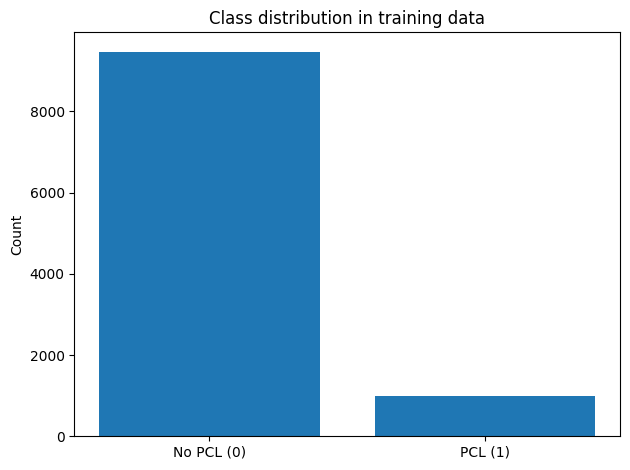

y
0    9476
1     993
Name: count, dtype: int64

In [13]:
counts = df["y"].value_counts().sort_index()
plt.figure()
plt.bar(["No PCL (0)", "PCL (1)"], [counts.get(0, 0), counts.get(1, 0)])
plt.title("Class distribution in training data")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("eda_images/eda_class_dist.png", dpi=200)
plt.show()
plt.close()
counts

In [10]:
def length_summary(group):
    x = group["n_tokens"]
    return pd.Series({
        "count": len(x),
        "min": int(x.min()),
        "mean": float(x.mean()),
        "median": float(x.median()),
        "p95": float(np.percentile(x, 95)),
        "max": int(x.max()),
    })

length_table = df.groupby("y").apply(length_summary)
display(length_table)
length_table.to_csv("eda_images/eda_length_table.csv")

,count,min,mean,median,p95,max
y,,,,,,
0,9476.0,0.0,42.817645,37.0,90.0,821.0
1,993.0,6.0,48.050352,42.0,101.8,458.0


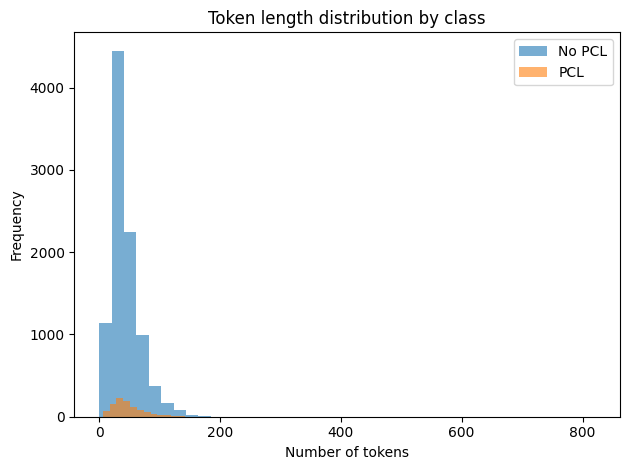

In [12]:
plt.figure()
for y, label in [(0, "No PCL"), (1, "PCL")]:
    vals = df[df["y"] == y]["n_tokens"]
    plt.hist(vals, bins=40, alpha=0.6, label=label)
plt.title("Token length distribution by class")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("eda_images/eda_length_hist.png", dpi=200)
plt.close()

In [14]:
def top_associated_ngrams(df, n=1, topk=15, min_total_count=5):
    class_counts = {0: Counter(), 1: Counter()}
    totals = {0: 0, 1: 0}

    for y, toks in zip(df["y"], df["tokens"]):
        if n == 1:
            grams = toks
        else:
            if len(toks) < n:
                continue
            grams = [" ".join(toks[i:i + n]) for i in range(len(toks) - n + 1)]
        class_counts[y].update(grams)
        totals[y] += len(grams)

    vocab = set(class_counts[0]) | set(class_counts[1])
    vocab = [g for g in vocab if (class_counts[0][g] + class_counts[1][g]) >= min_total_count]
    V = len(vocab)
    alpha = 1.0

    scores = []
    for g in vocab:
        c1 = class_counts[1][g]
        c0 = class_counts[0][g]
        p1 = (c1 + alpha) / (totals[1] + alpha * V)
        p0 = (c0 + alpha) / (totals[0] + alpha * V)
        score = float(np.log(p1 / p0))
        scores.append((g, score, c1, c0, c1 + c0))

    scores.sort(key=lambda x: x[1], reverse=True)
    top_pcl = scores[:topk]
    top_nopcl = sorted(scores, key=lambda x: x[1])[:topk]
    return top_pcl, top_nopcl

In [16]:
top_uni_pcl, top_uni_nopcl = top_associated_ngrams(df, n=1, topk=15, min_total_count=20)
top_bi_pcl, top_bi_nopcl = top_associated_ngrams(df, n=2, topk=15, min_total_count=10)

uni_table = pd.DataFrame(top_uni_pcl, columns=["token", "log_ratio", "count_pcl", "count_nopcl", "total"])
uni_table2 = pd.DataFrame(top_uni_nopcl, columns=["token", "log_ratio", "count_pcl", "count_nopcl", "total"])

bi_table = pd.DataFrame(top_bi_pcl, columns=["bigram", "log_ratio", "count_pcl", "count_nopcl", "total"])
bi_table2 = pd.DataFrame(top_bi_nopcl, columns=["bigram", "log_ratio", "count_pcl", "count_nopcl", "total"])

print("Top PCL tokens:")
display(uni_table.head(10))
print("Top No-PCL tokens:")
display(uni_table2.head(10))

Top PCL tokens:


,token,log_ratio,count_pcl,count_nopcl,total
0,hungry,2.876419,23,10,33
1,hearts,2.858400,14,6,20
2,christmas,2.664244,29,16,45
3,donate,2.588737,17,10,27
4,destitute,2.358625,12,9,21
5,needy,2.337422,13,10,23
6,dignity,2.319404,14,11,25
7,god,2.241442,36,31,67
8,pope,2.009249,10,11,21
9,francis,2.009249,10,11,21


Top No-PCL tokens:


,token,log_ratio,count_pcl,count_nopcl,total
0,anti,-2.298189,1,161,162
1,released,-2.123247,0,67,67
2,illegal,-2.060388,6,446,452
3,hopelessly,-1.981277,3,235,238
4,election,-1.929091,1,111,112
5,issued,-1.911073,0,54,54
6,eu,-1.883421,1,106,107
7,compared,-1.874032,0,52,52
8,technology,-1.874032,0,52,52
9,influx,-1.854983,0,51,51


## Visualising token and bigram associations

The helper utilities below reproduce the charts from `visualise_eda.py` while keeping everything in the same notebook.

In [21]:
EDA_RESULTS_DIR = Path("eda_images")

def plot_side_by_side(left_df, right_df, left_title, right_title, label_col, out_path: Path):
    left_df = left_df.sort_values("log_ratio", ascending=True)
    right_df = right_df.sort_values("log_ratio", ascending=True)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=False)
    axes[0].barh(left_df[label_col], left_df["log_ratio"])
    axes[0].set_title(left_title)
    axes[0].set_xlabel("log_ratio (PCL vs No-PCL)")

    axes[1].barh(right_df[label_col], right_df["log_ratio"])
    axes[1].set_title(right_title)
    axes[1].set_xlabel("log_ratio (PCL vs No-PCL)")

    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

def plot_diverging(pcl_df, nopcl_df, label_col, out_path: Path, title: str):
    pcl_df = pcl_df.copy()
    nopcl_df = nopcl_df.copy()

    if nopcl_df["log_ratio"].mean() > 0:
        nopcl_df["log_ratio"] = -nopcl_df["log_ratio"].abs()

    combined = pd.concat([pcl_df, nopcl_df], ignore_index=True)
    combined = combined.sort_values("log_ratio", ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(combined[label_col], combined["log_ratio"])
    plt.axvline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("log_ratio (PCL positive, No-PCL negative)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    plt.close()

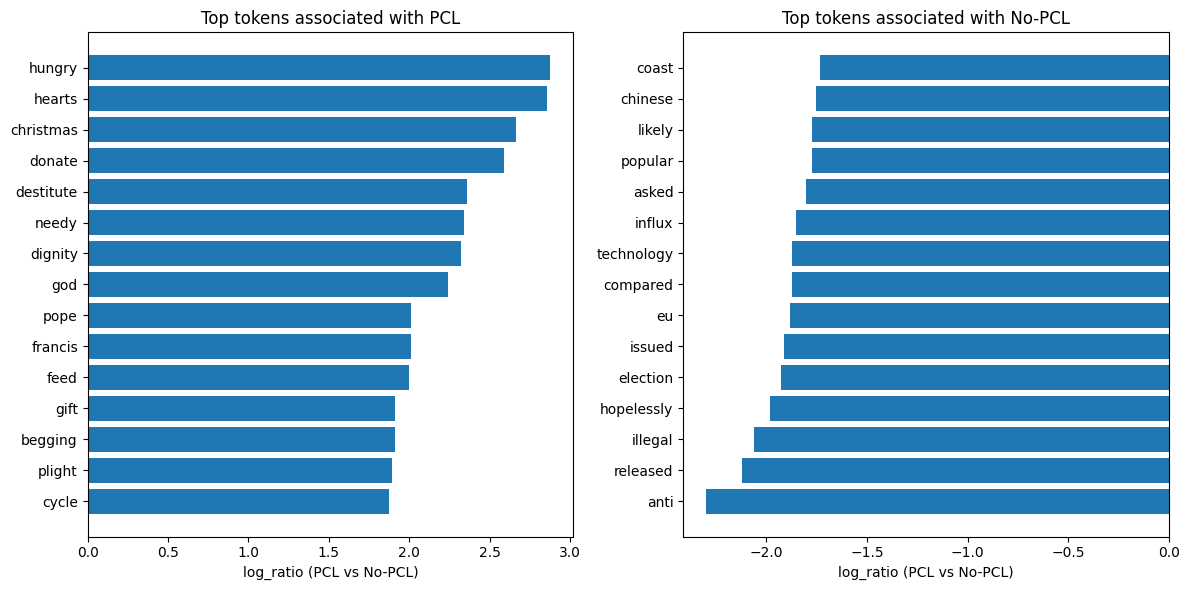

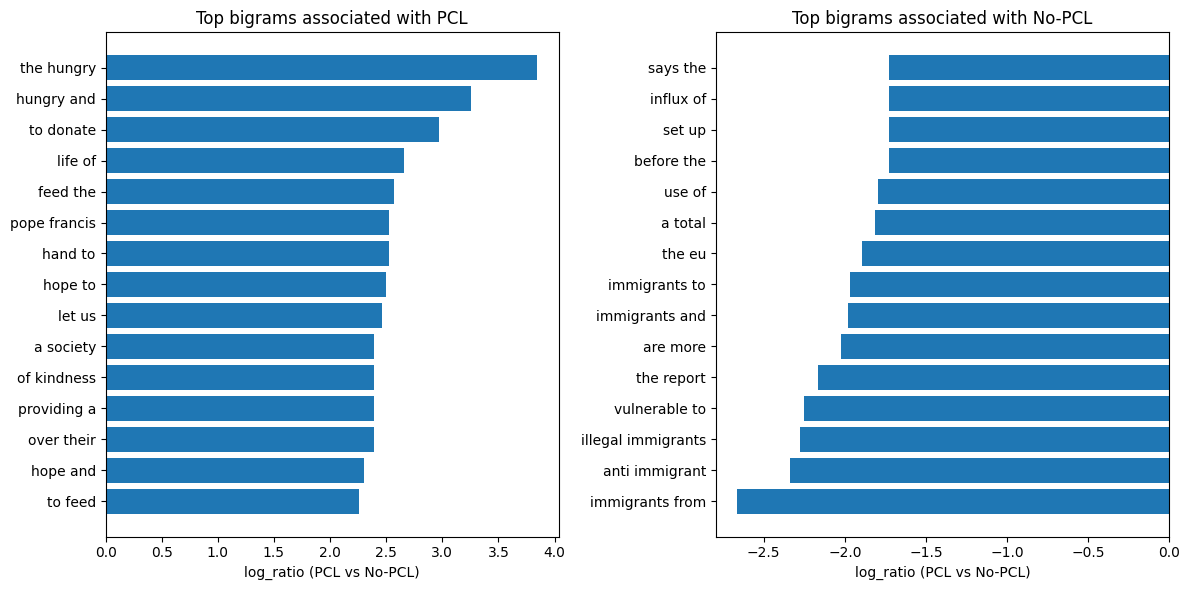

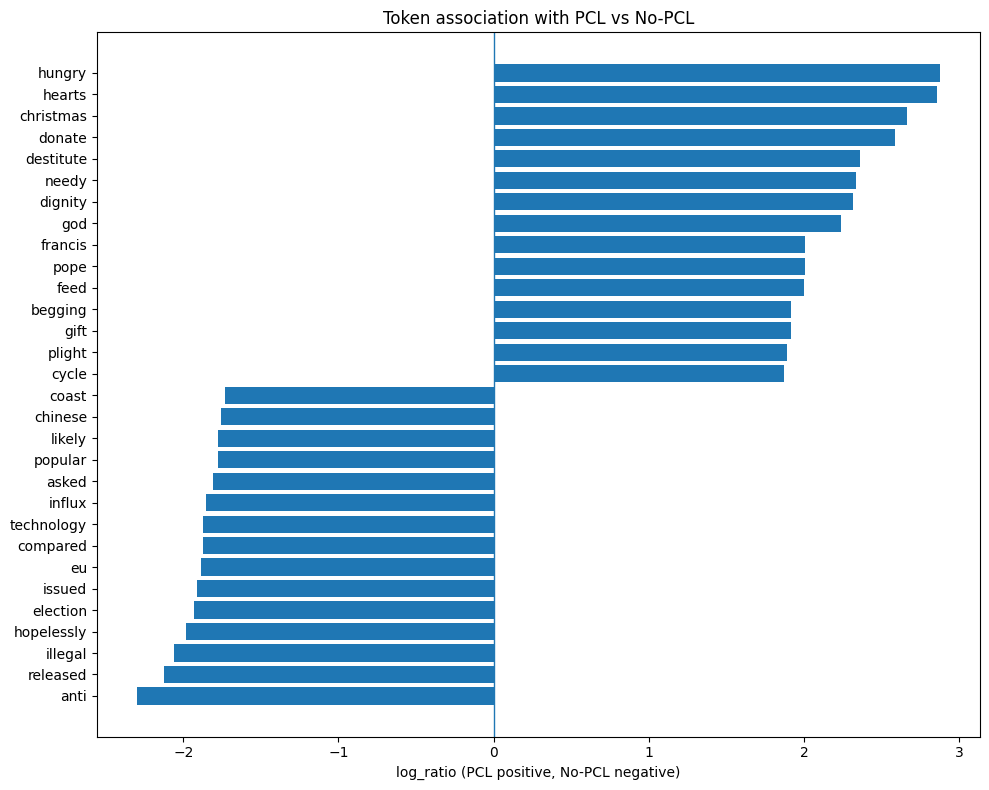

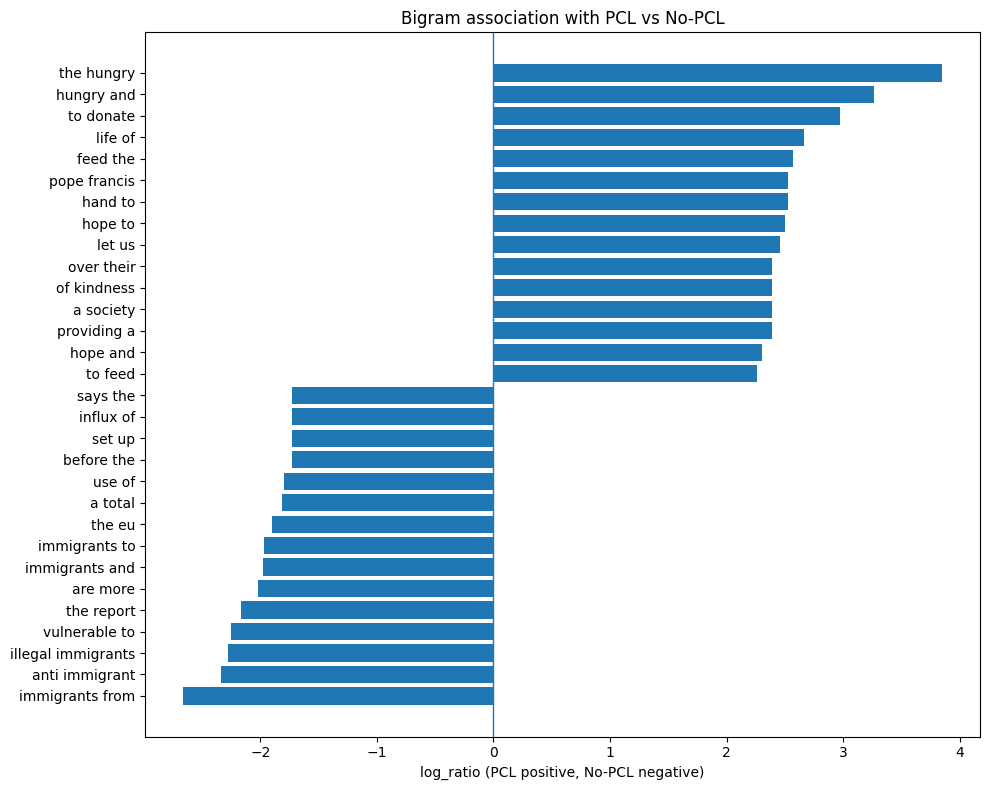

Saved visualisations to /home/aaronthomas/ImperialProgramming/Fourth_Yr/NLP/CW/BestModel/eda/eda_images


In [23]:
EDA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plot_side_by_side(
    uni_table,
    uni_table2,
    "Top tokens associated with PCL",
    "Top tokens associated with No-PCL",
    "token",
    EDA_RESULTS_DIR / "viz_top_tokens_side_by_side.png"
)

plot_side_by_side(
    bi_table,
    bi_table2,
    "Top bigrams associated with PCL",
    "Top bigrams associated with No-PCL",
    "bigram",
    EDA_RESULTS_DIR / "viz_top_bigrams_side_by_side.png"
)

plot_diverging(
    uni_table,
    uni_table2,
    "token",
    EDA_RESULTS_DIR / "viz_top_tokens_diverging.png",
    "Token association with PCL vs No-PCL"
)

plot_diverging(
    bi_table,
    bi_table2,
    "bigram",
    EDA_RESULTS_DIR / "viz_top_bigrams_diverging.png",
    "Bigram association with PCL vs No-PCL"
)

print(f"Saved visualisations to {EDA_RESULTS_DIR.resolve()}")

In [27]:
dup_mask = df.duplicated(subset=["text"], keep=False)
dups = df[dup_mask].sort_values("text")

print("Duplicate text rows:", dup_mask.sum())
print("Unique duplicate groups:", dups["text"].nunique())

patterns = {
    "has_html_entity_amp": r"&amp;",
    "has_html_tag": r"<[^>]+>",
    "has_newline": r"\n",
    "has_url": r"http[s]?://|www\.",
}

artifact_rows = []
for name, pat in patterns.items():
    artifact_rows.append((name, int(df["text"].str.contains(pat, regex=True).sum())))

artifact_df = pd.DataFrame(artifact_rows, columns=["artifact", "count"])
artifact_df["percent"] = 100 * artifact_df["count"] / len(df)
print(artifact_df)

examples = df[df["text"].str.contains(patterns["has_html_tag"], regex=True)][["idx", "text"]].head(10)



Duplicate text rows: 0
Unique duplicate groups: 0
              artifact  count   percent
0  has_html_entity_amp     61  0.582673
1         has_html_tag    401  3.830356
2          has_newline      0  0.000000
3              has_url      9  0.085968


In [28]:
p50 = np.percentile(df["n_tokens"], 50)
p95 = np.percentile(df["n_tokens"], 95)
p99 = np.percentile(df["n_tokens"], 99)
mx = df["n_tokens"].max()

outlier_stats = pd.DataFrame([
    {"p50": p50, "p95": p95, "p99": p99, "max": mx}
])
print("Token count summary (percentiles & max):")
display(outlier_stats)

longest = df.sort_values("n_tokens", ascending=False)[["idx", "n_tokens", "text", "y"]].head(10)
print("Longest examples:")
display(longest)

shortest = df[df["n_tokens"] > 0].sort_values("n_tokens")[["idx", "n_tokens", "text", "y"]].head(10)
print("Shortest non-empty examples:")
display(shortest)

Token count summary (percentiles & max):


,p50,p95,p99,max
0,38.0,91.0,128.0,821


Longest examples:


,idx,n_tokens,text,y
7418,7419,821,Dr Mayengbam Lalit Singh Recently honourable P...,0
6832,6833,458,Most are from desperately poor Horn of Africa ...,1
5977,5978,378,"Mahinda Wijesinghe , the Inspector General of ...",0
8191,8192,360,ANNUAL State of Education Report ( ASER ) laun...,0
9810,9811,259,Two goals in the third quarter put the Ballysh...,0
292,293,228,The following is a brief history of the Rajnee...,0
7852,7853,224,Islamic philosophy has dealt at length with th...,1
5493,5494,211,The importance of an assessment to evaluate th...,0
6314,6315,207,I ran into one of my high school teachers rece...,0
7809,7810,189,Equally to coincide with the 20th anniversary ...,0


Shortest non-empty examples:


,idx,n_tokens,text,y
1656,1657,1,refugees,0
9063,9064,2,Feeling hopeless,0
4256,4257,3,Germans investigate 59 refugees,0
1954,1955,3,Review refugee law,0
6020,6021,3,Pretty much hopeless,0
317,318,3,The Filipino immigrant,0
9134,9135,3,Syrian refugee children .,0
3412,3413,4,"1.1-million to the disabled ,",0
9655,9656,4,Diet for women over 30 :,0
5131,5132,4,Focus on the homeless,0


In [ ]:
# TF-IDF baseline (1–2 grams) + Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

# --- split (stratified because class imbalance) ---
X_train, X_dev, y_train, y_dev = train_test_split(
    df["text"].astype(str),
    df["y"].astype(int),
    test_size=0.2,
    random_state=42,
    stratify=df["y"].astype(int),
)

# --- vectorize ---
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,               # ignore super-rare terms
    max_df=0.95,            # ignore extremely common terms
    sublinear_tf=True,
    strip_accents="unicode",
)

Xtr = tfidf.fit_transform(X_train)
Xdv = tfidf.transform(X_dev)

# --- model (class_weight helps imbalance) ---
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1,
)

clf.fit(Xtr, y_train)

# --- eval (macro-F1 + per-class report) ---
pred = clf.predict(Xdv)
print("Macro-F1:", f1_score(y_dev, pred, average="macro"))
print(classification_report(y_dev, pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_dev, pred))

# --- optional: quick threshold tuning on dev to improve minority F1 ---
proba = clf.predict_proba(Xdv)[:, 1]
best_t, best_f1 = 0.5, -1
for t in np.linspace(0.05, 0.95, 19):
    p = (proba >= t).astype(int)
    f1 = f1_score(y_dev, p, average="macro")
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"Best threshold (macro-F1): {best_t:.2f} -> {best_f1:.4f}")

# --- optional: inspect most predictive ngrams ---
feature_names = np.array(tfidf.get_feature_names_out())
coef = clf.coef_.ravel()

top_pos = feature_names[np.argsort(coef)[-20:]][::-1]  # most PCL-associated
top_neg = feature_names[np.argsort(coef)[:20]]         # most No-PCL-associated

print("\nTop PCL n-grams:", top_pos[:15])
print("Top No-PCL n-grams:", top_neg[:15])

/home/aaronthomas/ImperialProgramming/Fourth_Yr/NLP/CW/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Macro-F1: 0.675825681674585
              precision    recall  f1-score   support

           0     0.9483    0.8997    0.9234      1895
           1     0.3581    0.5327    0.4283       199

    accuracy                         0.8649      2094
   macro avg     0.6532    0.7162    0.6758      2094
weighted avg     0.8922    0.8649    0.8763      2094

Confusion matrix:
 [[1705  190]
 [  93  106]]
Best threshold (macro-F1): 0.55 -> 0.6850

Top PCL n-grams: ['homeless' 'hope' 'poverty' 'poor' 'life' 'help' 'need' 'lives'
 'children' 'christmas' 'in need' 'them' 'hungry' 'those' 'our']
Top No-PCL n-grams: ['immigrants' 'immigrant' 'vulnerable to' 'need of' 'hopelessly' 'illegal'
 'were' 'migrants' 'number' 'some' 'countries' 'which'
 'illegal immigrants' 'workers' 'before']
